# Assignment 2: PCA - Python Implementation
## Principal Component Analysis Exercises (18 Questions)

This notebook covers all 18 practical PCA exercises with complete implementations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Question 1: Mean-Centering Data
Calculate the mean of each feature, subtract the mean from each feature, and display the centered data.

In [2]:
# Question 1: Mean-Centering Data
X_q1 = np.array([
    [2, 1],
    [3, 2],
    [4, 3],
    [5, 4],
    [6, 5]
])

# Calculate the mean of each feature
mean_q1 = np.mean(X_q1, axis=0)
print("Mean of each feature:", mean_q1)

# Subtract the mean from each feature (centering)
X_centered_q1 = X_q1 - mean_q1
print("\nCentered data:")
print(X_centered_q1)

Mean of each feature: [4. 3.]

Centered data:
[[-2. -2.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  2.]]


## Question 2: Data Visualization and Distribution Analysis
Calculate mean, center data, plot original and centered data, and observe the distribution pattern.

Mean of each column: [3. 6.]
Centered data:
[[-2. -4.]
 [-1. -2.]
 [ 0.  0.]
 [ 1.  2.]
 [ 2.  4.]]


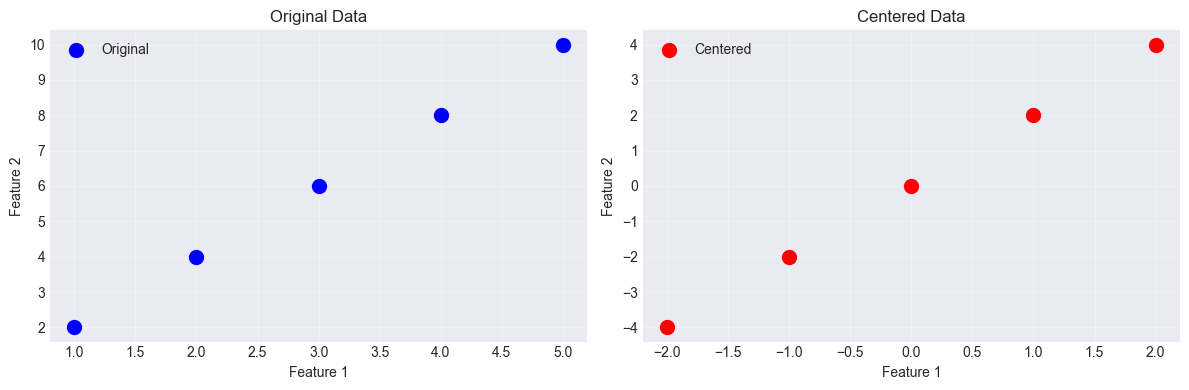


Observation: Data shows strong positive correlation along diagonal direction


In [3]:
# Question 2: Data Visualization
X_q2 = np.array([
    [1, 2],
    [2, 4],
    [3, 6],
    [4, 8],
    [5, 10]
])

# Calculate mean and center
mean_q2 = np.mean(X_q2, axis=0)
X_centered_q2 = X_q2 - mean_q2

print("Mean of each column:", mean_q2)
print("Centered data:")
print(X_centered_q2)

# Plot the data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X_q2[:, 0], X_q2[:, 1], color='blue', s=100, label='Original')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Original Data')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.scatter(X_centered_q2[:, 0], X_centered_q2[:, 1], color='red', s=100, label='Centered')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_title('Centered Data')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("\nObservation: Data shows strong positive correlation along diagonal direction")

## Question 3: Covariance Matrix Calculation
Calculate and display the covariance matrix, then identify variances of each feature.

In [4]:
# Question 3: Covariance Matrix
# Using centered data from Question 1
cov_matrix_q3 = np.cov(X_centered_q1.T)
print("Covariance matrix:")
print(cov_matrix_q3)

# Extract variances (diagonal elements)
variance_f1 = cov_matrix_q3[0, 0]
variance_f2 = cov_matrix_q3[1, 1]
covariance_between = cov_matrix_q3[0, 1]

print(f"\nVariance of Feature 1: {variance_f1}")
print(f"Variance of Feature 2: {variance_f2}")
print(f"Covariance between features: {covariance_between}")
print("\nNote: Strong positive covariance indicates correlation")

Covariance matrix:
[[2.5 2.5]
 [2.5 2.5]]

Variance of Feature 1: 2.5
Variance of Feature 2: 2.5
Covariance between features: 2.5

Note: Strong positive covariance indicates correlation


## Question 4: Comprehensive PCA Calculations
Mean, centering, and covariance matrix for a new dataset.

In [5]:
# Question 4: Comprehensive Calculations
X_q4 = np.array([
    [1, 2],
    [2, 3],
    [3, 5],
    [4, 7],
    [5, 8]
])

mean_q4 = np.mean(X_q4, axis=0)
X_centered_q4 = X_q4 - mean_q4
cov_matrix_q4 = np.cov(X_centered_q4.T)

print("Mean of each feature:", mean_q4)
print("\nCentered data:")
print(X_centered_q4)
print("\nCovariance matrix:")
print(cov_matrix_q4)

Mean of each feature: [3. 5.]

Centered data:
[[-2. -3.]
 [-1. -2.]
 [ 0.  0.]
 [ 1.  2.]
 [ 2.  3.]]

Covariance matrix:
[[2.5 4. ]
 [4.  6.5]]


## Question 5 & 6: Positively and Negatively Correlated Features
Compare covariance matrices of positive and negative correlation.

In [6]:
# Question 5: Positively Correlated Features
np.random.seed(42)
X_pos = np.random.rand(100, 1)
feature1_pos = X_pos.flatten()
feature2_pos = 2 * feature1_pos + np.random.normal(0, 0.1, 100)
data_pos = np.column_stack((feature1_pos, feature2_pos))

mean_pos = np.mean(data_pos, axis=0)
data_centered_pos = data_pos - mean_pos
cov_pos = np.cov(data_centered_pos.T)

print("Positive Correlation - Covariance Matrix:")
print(cov_pos)
print("\nOff-diagonal elements:", cov_pos[0, 1], "(POSITIVE)")

# Question 6: Negatively Correlated Features
feature1_neg = X_pos.flatten()
feature2_neg = -2 * feature1_neg + np.random.normal(0, 0.1, 100)
data_neg = np.column_stack((feature1_neg, feature2_neg))

mean_neg = np.mean(data_neg, axis=0)
data_centered_neg = data_neg - mean_neg
cov_neg = np.cov(data_centered_neg.T)

print("\n\nNegative Correlation - Covariance Matrix:")
print(cov_neg)
print("\nOff-diagonal elements:", cov_neg[0, 1], "(NEGATIVE)")

print("\n✓ Positive covariance: features move together")
print("✓ Negative covariance: features move in opposite directions")

Positive Correlation - Covariance Matrix:
[[0.08849995 0.17293091]
 [0.17293091 0.34605824]]

Off-diagonal elements: 0.17293090858665572 (POSITIVE)


Negative Correlation - Covariance Matrix:
[[ 0.08849995 -0.17691223]
 [-0.17691223  0.36569118]]

Off-diagonal elements: -0.1769122291117981 (NEGATIVE)

✓ Positive covariance: features move together
✓ Negative covariance: features move in opposite directions


## Questions 7-9: Eigenvalues and Eigenvectors
Calculate eigenvalues and eigenvectors, sort by importance.

In [7]:
# Question 7: Eigenvalues and Eigenvectors
C_q7 = np.array([[4, 2], [2, 3]])
eigenvalues_q7, eigenvectors_q7 = np.linalg.eig(C_q7)
print("Question 7:")
print("Eigenvalues:", eigenvalues_q7)
print("Eigenvectors:")
print(eigenvectors_q7)
max_eig_idx = np.argmax(eigenvalues_q7)
print("\nEigenvector for largest eigenvalue:", eigenvectors_q7[:, max_eig_idx])

# Question 8: Diagonal Covariance
C_q8 = np.array([[5, 0], [0, 2]])
eigenvalues_q8, eigenvectors_q8 = np.linalg.eig(C_q8)
print("\n\nQuestion 8:")
print("Eigenvalues:", eigenvalues_q8)
print("Eigenvectors:")
print(eigenvectors_q8)
print("\nFirst principal component (max eigenvalue=5):", eigenvectors_q8[:, 0])

# Question 9: Sort Components
C_q9 = np.array([[6, 4], [4, 3]])
eigenvalues_q9, eigenvectors_q9 = np.linalg.eig(C_q9)
idx_sort = np.argsort(eigenvalues_q9)[::-1]
eigenvalues_sorted = eigenvalues_q9[idx_sort]
eigenvectors_sorted = eigenvectors_q9[:, idx_sort]

print("\n\nQuestion 9:")
print("Original eigenvalues:", eigenvalues_q9)
print("Sorted eigenvalues (descending):", eigenvalues_sorted)
print("Sorted eigenvectors:")
print(eigenvectors_sorted)

Question 7:
Eigenvalues: [5.56155281 1.43844719]
Eigenvectors:
[[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]

Eigenvector for largest eigenvalue: [0.78820544 0.61541221]


Question 8:
Eigenvalues: [5. 2.]
Eigenvectors:
[[1. 0.]
 [0. 1.]]

First principal component (max eigenvalue=5): [1. 0.]


Question 9:
Original eigenvalues: [8.77200187 0.22799813]
Sorted eigenvalues (descending): [8.77200187 0.22799813]
Sorted eigenvectors:
[[ 0.82192562 -0.56959484]
 [ 0.56959484  0.82192562]]


## Question 10: PCA Implementation from Scratch (No sklearn)
Complete PCA pipeline: centering → covariance → eigendecomposition → projection

In [8]:
# Question 10: Complete PCA from Scratch
X_q10 = np.array([
    [2, 1],
    [3, 2],
    [4, 3],
    [5, 4],
    [6, 5]
])

# Step 1: Mean Centering
mean_q10 = np.mean(X_q10, axis=0)
X_centered_q10 = X_q10 - mean_q10
print("Step 1 - Centered data:")
print(X_centered_q10)

# Step 2: Covariance Matrix
cov_matrix_q10 = np.cov(X_centered_q10.T)
print("\nStep 2 - Covariance matrix:")
print(cov_matrix_q10)

# Step 3: Eigenvalues & Eigenvectors
eigenvalues_q10, eigenvectors_q10 = np.linalg.eig(cov_matrix_q10)
print("\nStep 3 - Eigenvalues:", eigenvalues_q10)
print("Eigenvectors:")
print(eigenvectors_q10)

# Step 4: Sort Components
idx = np.argsort(eigenvalues_q10)[::-1]
eigenvalues_q10 = eigenvalues_q10[idx]
eigenvectors_q10 = eigenvectors_q10[:, idx]

# Step 5 & 6: Select and Transform
n_components = 2
principal_components = eigenvectors_q10[:, :n_components]
X_pca_q10 = np.dot(X_centered_q10, principal_components)

print("\nStep 6 - Transformed data:")
print(X_pca_q10)
print(f"\nOriginal shape: {X_q10.shape}")
print(f"PCA shape: {X_pca_q10.shape}")

Step 1 - Centered data:
[[-2. -2.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  2.]]

Step 2 - Covariance matrix:
[[2.5 2.5]
 [2.5 2.5]]

Step 3 - Eigenvalues: [5.0000000e+00 4.4408921e-16]
Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Step 6 - Transformed data:
[[-2.82842712e+00 -2.22044605e-16]
 [-1.41421356e+00 -1.11022302e-16]
 [ 0.00000000e+00  0.00000000e+00]
 [ 1.41421356e+00  1.11022302e-16]
 [ 2.82842712e+00  2.22044605e-16]]

Original shape: (5, 2)
PCA shape: (5, 2)


## Question 11: Project Data onto First Principal Component

In [9]:
# Question 11: Project onto First PC
first_pc = eigenvectors_q10[:, 0]
print("First principal component:", first_pc)

X_1d = np.dot(X_centered_q10, first_pc)
print("\nOne-dimensional representation (projected onto PC1):")
print(X_1d)

First principal component: [0.70710678 0.70710678]

One-dimensional representation (projected onto PC1):
[-2.82842712 -1.41421356  0.          1.41421356  2.82842712]


## Question 12: Parameterized PCA Function

In [10]:
# Question 12: Custom PCA Function
def custom_pca(X, n_components):
    """Custom PCA implementation"""
    # Mean centering
    mean = np.mean(X, axis=0)
    X_centered = X - mean
    
    # Covariance matrix
    cov_matrix = np.cov(X_centered.T)
    
    # Eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Select components
    principal_components = eigenvectors[:, :n_components]
    
    # Transform
    X_pca = np.dot(X_centered, principal_components)
    
    return X_pca, principal_components, eigenvalues[:n_components]

# Test
X_test = np.array([[2, 1], [3, 2], [4, 3], [5, 4], [6, 5]])
X_reduced = custom_pca(X_test, n_components=1)
print("Reduced data (1D):")
print(X_reduced[0])

Reduced data (1D):
[[-2.82842712]
 [-1.41421356]
 [ 0.        ]
 [ 1.41421356]
 [ 2.82842712]]


## Question 13: Using scikit-learn PCA

In [11]:
# Question 13: Using sklearn PCA
X_q13 = np.array([[2, 1], [3, 2], [4, 3], [5, 4], [6, 5]])

pca_q13 = PCA(n_components=1)
X_transformed_q13 = pca_q13.fit_transform(X_q13)

print("Original data:")
print(X_q13)
print("\nTransformed data (1D):")
print(X_transformed_q13)
print("\nExplained variance ratio:", pca_q13.explained_variance_ratio_)
print(f"Total variance explained: {pca_q13.explained_variance_ratio_.sum():.2%}")

Original data:
[[2 1]
 [3 2]
 [4 3]
 [5 4]
 [6 5]]

Transformed data (1D):
[[ 2.82842712]
 [ 1.41421356]
 [-0.        ]
 [-1.41421356]
 [-2.82842712]]

Explained variance ratio: [1.]
Total variance explained: 100.00%


## Question 14: Reduce 3D to 2D and Visualize

Original 3D shape: (50, 3)
Reduced 2D shape: (50, 2)
Explained variance ratio: [0.43231008 0.38981332]
Total variance retained: 82.21%


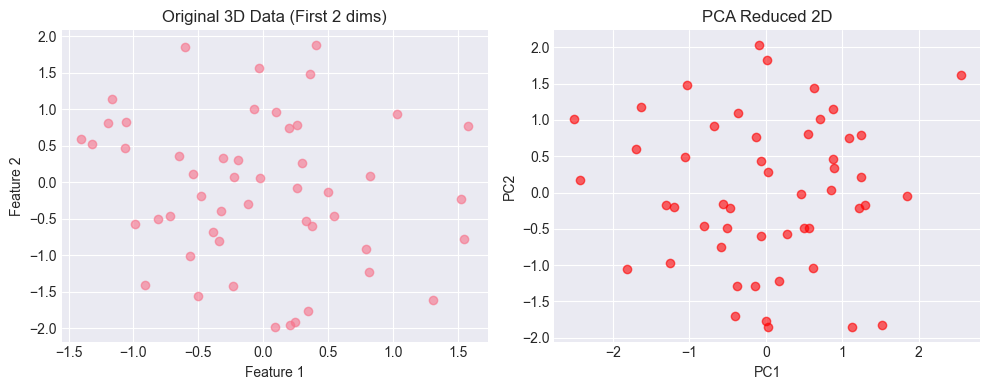

In [12]:
# Question 14: 3D to 2D Reduction
np.random.seed(42)
X_3d = np.random.randn(50, 3)

pca_3d = PCA(n_components=2)
X_2d = pca_3d.fit_transform(X_3d)

print("Original 3D shape:", X_3d.shape)
print("Reduced 2D shape:", X_2d.shape)
print("Explained variance ratio:", pca_3d.explained_variance_ratio_)
print(f"Total variance retained: {pca_3d.explained_variance_ratio_.sum():.2%}")

# Visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_3d[:, 0], X_3d[:, 1], alpha=0.6)
plt.title("Original 3D Data (First 2 dims)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, color='red')
plt.title("PCA Reduced 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Question 15: Variance Explained by Each Component

Variance explained by each component:
PC1: 0.4323 (43.23%)
PC2: 0.3898 (38.98%)
PC3: 0.1779 (17.79%)

Cumulative variance:
First 1 components: 0.4323 (43.23%)
First 2 components: 0.8221 (82.21%)
First 3 components: 1.0000 (100.00%)


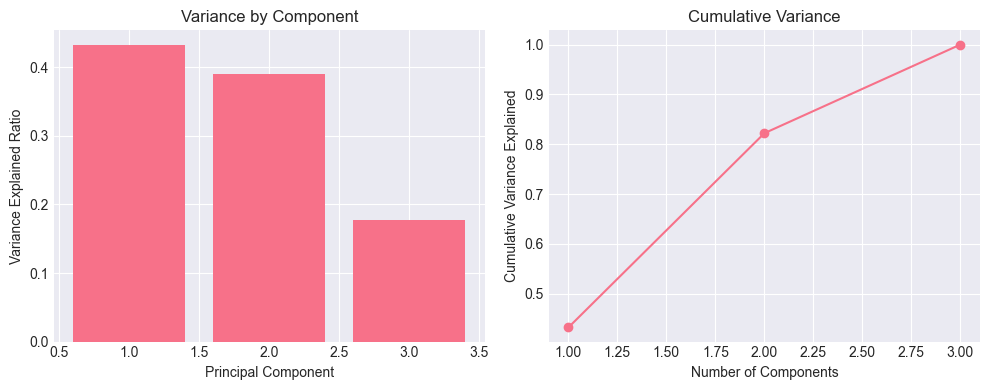

In [13]:
# Question 15: Variance Analysis
pca_all = PCA(n_components=3)
pca_all.fit(X_3d)

variance_ratio = pca_all.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

print("Variance explained by each component:")
for i, var in enumerate(variance_ratio):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print("\nCumulative variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"First {i+1} components: {cum_var:.4f} ({cum_var*100:.2f}%)")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, 4), variance_ratio)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained Ratio")
plt.title("Variance by Component")

plt.subplot(1, 2, 2)
plt.plot(range(1, 4), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Variance")
plt.tight_layout()
plt.show()

## Question 16: Visualization Comparison (Before/After Standardization)

Variance explained (without standardization): [1.00000000e+00 4.84579219e-36]
Variance explained (with standardization): [1.00000000e+00 3.69778549e-33]


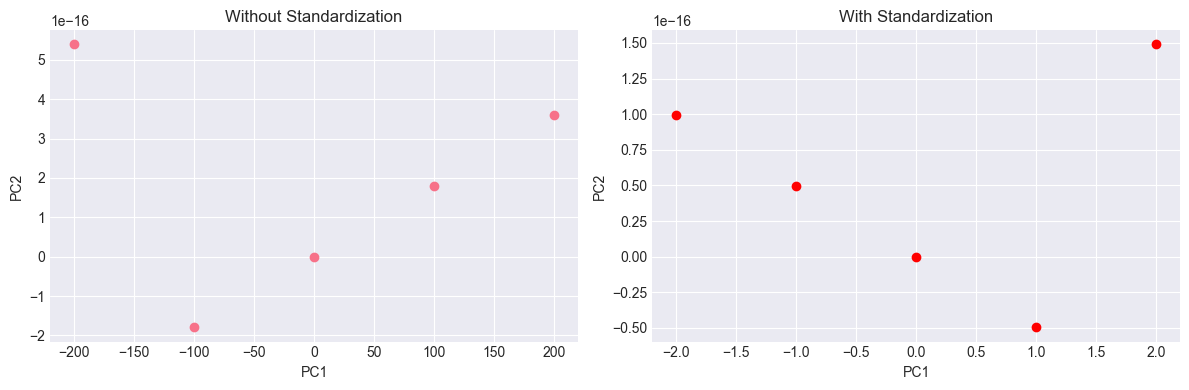

In [14]:
# Question 16: Comparison with/without Standardization
X_non_standard = np.array([
    [2, 100],
    [3, 200],
    [4, 300],
    [5, 400],
    [6, 500]
])

# Without standardization
pca_non_standard = PCA(n_components=2)
X_pca_non_standard = pca_non_standard.fit_transform(X_non_standard)

# With standardization
scaler = StandardScaler()
X_standard = scaler.fit_transform(X_non_standard)
pca_standard = PCA(n_components=2)
X_pca_standard = pca_standard.fit_transform(X_standard)

print("Variance explained (without standardization):", pca_non_standard.explained_variance_ratio_)
print("Variance explained (with standardization):", pca_standard.explained_variance_ratio_)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_pca_non_standard[:, 0], X_pca_non_standard[:, 1])
axes[0].set_title("Without Standardization")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca_standard[:, 0], X_pca_standard[:, 1], color='red')
axes[1].set_title("With Standardization")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

## Question 17: 3D Visualization of Principal Components

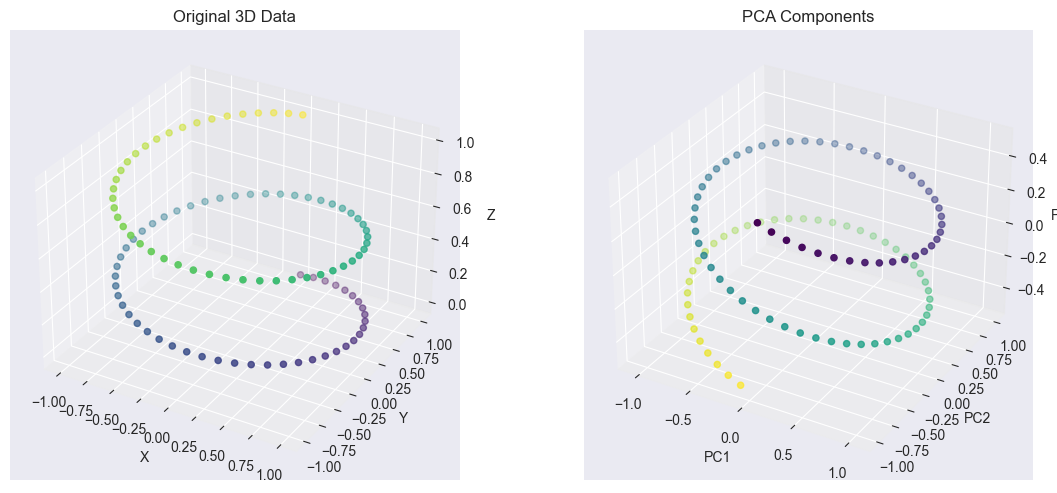

Explained variance ratio: [0.46969449 0.46538129 0.06492421]


In [15]:
# Question 17: 3D Visualization
from mpl_toolkits.mplot3d import Axes3D

# Create sample 3D data with structure
np.random.seed(42)
n_samples = 100
t = np.linspace(0, 4*np.pi, n_samples)
X_3d_sample = np.column_stack([
    np.sin(t),
    np.cos(t),
    t/max(t)
])

# Apply PCA with 3 components
pca_3_components = PCA(n_components=3)
X_3d_pca = pca_3_components.fit_transform(X_3d_sample)

# Create 3D plot
fig = plt.figure(figsize=(12, 5))

# Original data
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X_3d_sample[:, 0], X_3d_sample[:, 1], X_3d_sample[:, 2], c=range(n_samples), cmap='viridis')
ax1.set_title("Original 3D Data")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# PCA components
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_3d_pca[:, 0], X_3d_pca[:, 1], X_3d_pca[:, 2], c=range(n_samples), cmap='viridis')
ax2.set_title("PCA Components")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")

plt.tight_layout()
plt.show()

print(f"Explained variance ratio: {pca_3_components.explained_variance_ratio_}")

## Question 18: Complete Pipeline Example (Iris Dataset)

Original data shape: (150, 4)
After PCA shape: (150, 2)

Explained variance ratio: [0.84349293 0.08323359]
Total variance explained: 92.67%


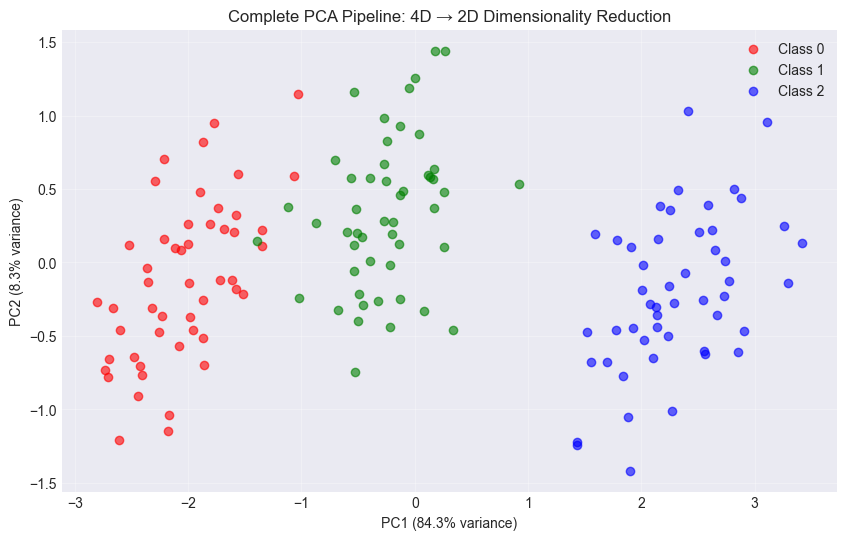

In [16]:
# Question 18: Complete PCA Pipeline
# Create synthetic iris-like dataset
np.random.seed(42)
n_samples = 150
n_features = 4

# Simulate 3 classes (0, 1, 2)
X_iris_sim = []
y_iris_sim = []
for class_label in range(3):
    center = np.random.randn(n_features) * 0.5 + class_label * 1.5
    X_class = np.random.randn(n_samples//3, n_features) * 0.5 + center
    X_iris_sim.append(X_class)
    y_iris_sim.extend([class_label] * (n_samples//3))

X_iris_sim = np.vstack(X_iris_sim)
y_iris_sim = np.array(y_iris_sim)

# Step 1: Standardization
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris_sim)

# Step 2: Apply PCA
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

# Step 3: Summary
print("Original data shape:", X_iris_sim.shape)
print("After PCA shape:", X_iris_pca.shape)
print("\nExplained variance ratio:", pca_iris.explained_variance_ratio_)
print(f"Total variance explained: {pca_iris.explained_variance_ratio_.sum():.2%}")

# Step 4: Visualization
colors = ['red', 'green', 'blue']
plt.figure(figsize=(10, 6))
for class_label in range(3):
    mask = y_iris_sim == class_label
    plt.scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1], 
               label=f"Class {class_label}", color=colors[class_label], alpha=0.6)

plt.xlabel(f"PC1 ({pca_iris.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_iris.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Complete PCA Pipeline: 4D → 2D Dimensionality Reduction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()